# 04 – Supervised Baseline

In diesem Notebook wird ein AstroNet-artiges 1D-CNN für die binäre
Klassifikation von TESS-Lichtkurven trainiert.

Die Eingaben stammen aus Notebook 03 und sind folgende:

- Global View mit 201 Bins
- Local View mit 61 Bins
- Label 0: Nicht-Planet
- Label 1: Planet

Zunächst wird das Modell vollständig supervised und ohne Pretraining
von Grund auf trainiert.

Anschließend werden zusätzliche Baselines mit reduzierten Anteilen der
verfügbaren, folgenden Trainingslabels erstellt:

- 100 %
- 50 %
- 25 %
- 10 %

Validation und Test bleiben für alle Experimente unverändert.
Insbesondere wird der Testdatensatz im Training nicht verwendet.

Alle folgenden Experimente werden mit fünf festgelegten Seeds wiederholt.
ROC-AUC ist die primäre Vergleichsmetrik; die übrigen Klassifikationsmetriken
werden ergänzend als Mittelwert und Standardabweichung dargestellt.

Die Ergebnisse dienen später als Vergleichsbasis für das
Self-Supervised Pretraining.

### Datengrundlage

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import average_precision_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
import seaborn as sns

#### Reproduzierbarkeit sicherstellen

In [2]:
SEED = 42
EXPERIMENT_SEEDS = [7, 21, 42, 84, 123]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("PyTorch-Version:", torch.__version__)
print("Gerät:", device)

if device.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

PyTorch-Version: 2.13.0+cu130
Gerät: cuda
GPU: NVIDIA GeForce RTX 4070


In [3]:
cwd = Path.cwd()

if cwd.name.lower() == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "spoc120_dataset"
)

VIEWS_FILE = (
    DATA_DIR
    / "spoc120_views.npz"
)

METADATA_FILE = (
    DATA_DIR
    / "spoc120_metadata.csv"
)

print("Projekt:", PROJECT_ROOT)
print("Views:", VIEWS_FILE)
print("Metadaten:", METADATA_FILE)

print()
print("Views vorhanden:", VIEWS_FILE.exists())
print(
    "Metadaten vorhanden:",
    METADATA_FILE.exists()
)

Projekt: c:\Users\User\Documents\VanessaExoplanets\Exoplanets
Views: c:\Users\User\Documents\VanessaExoplanets\Exoplanets\data\processed\spoc120_dataset\spoc120_views.npz
Metadaten: c:\Users\User\Documents\VanessaExoplanets\Exoplanets\data\processed\spoc120_dataset\spoc120_metadata.csv

Views vorhanden: True
Metadaten vorhanden: True


### Datensatz laden und Modelleingaben skalieren

Relative Fluxwerte liegen typischerweise im Bereich 1e-3.
Extreme Einzelwerte werden vor der Umrechnung in parts per thousand begrenzt, damit sie die Optimierung nicht dominieren.

In [4]:
with np.load(
    VIEWS_FILE,
    allow_pickle=False
) as dataset:
    X_global = dataset["X_global"]
    X_local = dataset["X_local"]
    y = dataset["y"]


FLUX_CLIP_RELATIVE = 0.02
FLUX_TO_PPT = 1000.0


def prepare_model_views(values):
    return (
        np.clip(
            values,
            -FLUX_CLIP_RELATIVE,
            FLUX_CLIP_RELATIVE
        )
        * FLUX_TO_PPT
    ).astype(np.float32, copy=False)


X_global = prepare_model_views(X_global)
X_local = prepare_model_views(X_local)

metadata = pd.read_csv(
    METADATA_FILE
)

print(
    "X_global:",
    X_global.shape,
    X_global.dtype
)

print(
    "X_local:",
    X_local.shape,
    X_local.dtype
)

print(
    "y:",
    y.shape,
    y.dtype
)

print(
    "Metadaten:",
    metadata.shape
)

print()
print("Flux-Einheit: ppt")
print("Clipping vor Skalierung: ±", FLUX_CLIP_RELATIVE)

X_global: (2282, 201) float32
X_local: (2282, 61) float32
y: (2282,) int64
Metadaten: (2282, 31)

Flux-Einheit: ppt
Clipping vor Skalierung: ± 0.02


#### Splits und Klassenverteilung prüfen

In [5]:
print(
    metadata["split"]
    .value_counts()
)

print()

print(
    metadata["label"]
    .value_counts()
    .sort_index()
)

print()

print(
    pd.crosstab(
        metadata["split"],
        metadata["label"]
    )
)

split
train         1596
test           344
validation     342
Name: count, dtype: int64

label
0    1047
1    1235
Name: count, dtype: int64

label         0    1
split               
test        157  187
train       732  864
validation  158  184


In [6]:
train_indices = np.flatnonzero(
    metadata["split"].to_numpy() == "train"
)

validation_indices = np.flatnonzero(
    metadata["split"].to_numpy() == "validation"
)

test_indices = np.flatnonzero(
    metadata["split"].to_numpy() == "test"
)

print("Training:", len(train_indices))
print("Validation:", len(validation_indices))
print("Test:", len(test_indices))

print(
    "Gesamt:",
    len(train_indices)
    + len(validation_indices)
    + len(test_indices)
)

Training: 1596
Validation: 342
Test: 344
Gesamt: 2282


#### Dataset definieren

In [7]:
class LightCurveDataset(Dataset):
    def __init__(
        self,
        X_global,
        X_local,
        y,
        indices
    ):
        self.X_global = X_global
        self.X_local = X_local
        self.y = y
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        sample_index = self.indices[index]

        global_view = torch.tensor(
            self.X_global[sample_index],
            dtype=torch.float32
        ).unsqueeze(0)

        local_view = torch.tensor(
            self.X_local[sample_index],
            dtype=torch.float32
        ).unsqueeze(0)

        label = torch.tensor(
            self.y[sample_index],
            dtype=torch.float32
        )

        return global_view, local_view, label

#### Erzeuge Train-, Validation- und Test-Dataset

In [8]:
train_dataset = LightCurveDataset(
    X_global,
    X_local,
    y,
    train_indices
)

validation_dataset = LightCurveDataset(
    X_global,
    X_local,
    y,
    validation_indices
)

test_dataset = LightCurveDataset(
    X_global,
    X_local,
    y,
    test_indices
)

print("Training:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Test:", len(test_dataset))

Training: 1596
Validation: 342
Test: 344


#### Einzelnes Dataset-Sample prüfen

In [9]:
global_view, local_view, label = train_dataset[0]

print(
    "Global View:",
    global_view.shape,
    global_view.dtype
)

print(
    "Local View:",
    local_view.shape,
    local_view.dtype
)

print(
    "Label:",
    label.shape,
    label.dtype,
    label.item()
)

Global View: torch.Size([1, 201]) torch.float32
Local View: torch.Size([1, 61]) torch.float32
Label: torch.Size([]) torch.float32 1.0


#### Dataloader erstellen

In [10]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train-Batches:", len(train_loader))
print("Validation-Batches:", len(validation_loader))
print("Test-Batches:", len(test_loader))

Train-Batches: 50
Validation-Batches: 11
Test-Batches: 11


#### Batch aus dem DataLoader prüfen

In [11]:
global_batch, local_batch, label_batch = next(
    iter(train_loader)
)

print(
    "Global Batch:",
    global_batch.shape,
    global_batch.dtype
)

print(
    "Local Batch:",
    local_batch.shape,
    local_batch.dtype
)

print(
    "Label Batch:",
    label_batch.shape,
    label_batch.dtype
)

print(
    "Labels im Batch:",
    label_batch
)

Global Batch: torch.Size([32, 1, 201]) torch.float32
Local Batch: torch.Size([32, 1, 61]) torch.float32
Label Batch: torch.Size([32]) torch.float32
Labels im Batch: tensor([0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 1.,
        1., 1., 1., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1.])


### 1D-CNN-Encoder und AstroNet-artiges Modell definieren

In [12]:
POOL_OUTPUT_SIZE = 8
ENCODER_CHANNELS = 64
ENCODED_FEATURES = ENCODER_CHANNELS * POOL_OUTPUT_SIZE


class LightCurveEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(
                in_channels=1,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(
                in_channels=32,
                out_channels=64,
                kernel_size=5,
                padding=2
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.AdaptiveAvgPool1d(POOL_OUTPUT_SIZE)
        )

    def forward(self, x):
        x = self.features(x)
        return torch.flatten(x, start_dim=1)


class AstroNetClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.global_encoder = LightCurveEncoder()
        self.local_encoder = LightCurveEncoder()

        self.classifier = nn.Sequential(
            nn.Linear(2 * ENCODED_FEATURES, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(
        self,
        global_view,
        local_view
    ):
        global_features = self.global_encoder(
            global_view
        )

        local_features = self.local_encoder(
            local_view
        )

        combined = torch.cat(
            [
                global_features,
                local_features
            ],
            dim=1
        )

        return self.classifier(
            combined
        ).squeeze(1)

#### Modell erzeugen und Forward Pass testen

In [13]:
model = AstroNetClassifier().to(device)

global_batch = global_batch.to(device)
local_batch = local_batch.to(device)

with torch.no_grad():
    output = model(
        global_batch,
        local_batch
    )

print("Modellgerät:", next(model.parameters()).device)
print("Output-Shape:", output.shape)
print("Erste Outputs:", output[:5])

Modellgerät: cuda:0
Output-Shape: torch.Size([32])
Erste Outputs: tensor([ 0.0742,  0.0350,  0.0867, -0.2157,  0.0853], device='cuda:0')


In [14]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Parameter gesamt:", total_params)
print("Trainierbare Parameter:", trainable_params)

Parameter gesamt: 152321
Trainierbare Parameter: 152321


#### Loss-Funktion und Optimizer

In [15]:
LEARNING_RATE = 0.001

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning Rate:", LEARNING_RATE)

Loss: BCEWithLogitsLoss()
Optimizer: Adam
Learning Rate: 0.001


#### Trainingsfunktion für eine Epoche

In [16]:
def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0

    for (
        global_view,
        local_view,
        labels
    ) in data_loader:

        global_view = global_view.to(device)
        local_view = local_view.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(
            global_view,
            local_view
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += (
            loss.item()
            * labels.size(0)
        )

    epoch_loss = (
        running_loss
        / len(data_loader.dataset)
    )

    return epoch_loss

#### Validation-Funktion

In [17]:
def evaluate_loss(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0

    with torch.no_grad():
        for (
            global_view,
            local_view,
            labels
        ) in data_loader:

            global_view = global_view.to(device)
            local_view = local_view.to(device)
            labels = labels.to(device)

            outputs = model(
                global_view,
                local_view
            )

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item()
                * labels.size(0)
            )

    epoch_loss = (
        running_loss
        / len(data_loader.dataset)
    )

    return epoch_loss

#### Training mit Early Stopping

In [19]:
def train_model(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    device,
    max_epochs=50,
    patience=8,
    verbose=True
):
    train_losses = []
    validation_losses = []

    best_validation_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        validation_loss = evaluate_loss(
            model,
            validation_loader,
            criterion,
            device
        )

        train_losses.append(train_loss)
        validation_losses.append(validation_loss)

        if verbose:
            print(
                f"Epoch {epoch + 1:02d} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Validation Loss: {validation_loss:.4f}"
            )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss

            best_state = {
                key: value.detach().cpu().clone()
                for key, value
                in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            if verbose:
                print(
                    "Early Stopping nach "
                    f"{epoch + 1} Epochen."
                )
            break

    model.load_state_dict(best_state)

    return (
        model,
        train_losses,
        validation_losses
    )

#### Seed-Funktion für reproduzierbare Experimente

In [20]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)
print("Gerät:", device)

Gerät: cuda


#### Trainingsparameter

In [21]:
MAX_EPOCHS = 100
PATIENCE = 20

print("Maximale Epochen:", MAX_EPOCHS)
print("Early-Stopping-Patience:", PATIENCE)

Maximale Epochen: 100
Early-Stopping-Patience: 20


#### Baseline mit 100 % der Trainingslabels trainieren

In [22]:
baseline_models = {}
baseline_histories = {}

for experiment_seed in EXPERIMENT_SEEDS:
    set_seed(experiment_seed)

    loader_generator = torch.Generator()
    loader_generator.manual_seed(experiment_seed)

    seeded_train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        generator=loader_generator
    )

    current_model = AstroNetClassifier().to(device)
    current_optimizer = torch.optim.Adam(
        current_model.parameters(),
        lr=LEARNING_RATE
    )

    current_model, current_train_losses, current_validation_losses = (
        train_model(
            current_model,
            seeded_train_loader,
            validation_loader,
            criterion,
            current_optimizer,
            device,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            verbose=False
        )
    )

    baseline_models[experiment_seed] = current_model
    baseline_histories[experiment_seed] = {
        "train_loss": current_train_losses,
        "validation_loss": current_validation_losses
    }

    print(
        f"Seed {experiment_seed}: "
        f"beste Epoche "
        f"{np.argmin(current_validation_losses) + 1}, "
        f"{len(current_train_losses)} Epochen trainiert"
    )

# Seed 42 bleibt der vorab festgelegte Referenzlauf für die Einzelplots.
baseline_model = baseline_models[SEED]
train_losses = baseline_histories[SEED]["train_loss"]
validation_losses = baseline_histories[SEED]["validation_loss"]

Seed 7: beste Epoche 15, 35 Epochen trainiert
Seed 21: beste Epoche 9, 29 Epochen trainiert
Seed 42: beste Epoche 12, 32 Epochen trainiert
Seed 84: beste Epoche 13, 33 Epochen trainiert
Seed 123: beste Epoche 8, 28 Epochen trainiert


### Auswertung der Baseline über fünf Seeds

In [23]:
def predict_probabilities(
    model,
    data_loader,
    device
):
    all_probabilities = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for (
            global_view,
            local_view,
            labels
        ) in data_loader:

            global_view = global_view.to(device)
            local_view = local_view.to(device)

            logits = model(
                global_view,
                local_view
            )

            probabilities = torch.sigmoid(
                logits
            )

            all_probabilities.append(
                probabilities.cpu()
            )

            all_labels.append(
                labels.cpu()
            )

    return (
        torch.cat(all_probabilities),
        torch.cat(all_labels)
    )


validation_probabilities, validation_labels = (
    predict_probabilities(
        baseline_model,
        validation_loader,
        device
    )
)

validation_predictions = (
    validation_probabilities >= 0.5
).float()

accuracy = (
    validation_predictions
    == validation_labels
).float().mean()

print(
    "Minimum:",
    validation_probabilities.min().item()
)

print(
    "Maximum:",
    validation_probabilities.max().item()
)

print(
    "Mittelwert:",
    validation_probabilities.mean().item()
)

print(
    "Standardabweichung:",
    validation_probabilities.std().item()
)

print()

print(
    "Vorhergesagte Klassen:",
    torch.bincount(
        validation_predictions.long(),
        minlength=2
    )
)

print(
    "Accuracy:",
    accuracy.item()
)

Minimum: 4.960293864542109e-08
Maximum: 0.9999097585678101
Mittelwert: 0.5604375600814819
Standardabweichung: 0.272460013628006

Vorhergesagte Klassen: tensor([129, 213])
Accuracy: 0.7456140518188477


In [65]:
THRESHOLD = 0.5
PRIMARY_METRIC = "roc_auc"
METRIC_COLUMNS = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "average_precision"
]


def calculate_metrics(labels, probabilities):
    y_true = labels.numpy().astype(int)
    y_prob = probabilities.numpy()
    y_pred = (y_prob >= THRESHOLD).astype(int)

    return {
        "accuracy": float(np.mean(y_pred == y_true)),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "average_precision": average_precision_score(y_true, y_prob)
    }


validation_rows = []

for experiment_seed, experiment_model in baseline_models.items():
    probabilities, labels = predict_probabilities(
        experiment_model,
        validation_loader,
        device
    )
    validation_rows.append({
        "seed": experiment_seed,
        **calculate_metrics(labels, probabilities)
    })

validation_results = pd.DataFrame(validation_rows)
validation_summary = (
    validation_results[METRIC_COLUMNS]
    .agg(["mean", "std"])
    .T
)

display(validation_results)
display(validation_summary.style.format("{:.4f}"))

primary_validation = validation_summary.loc[PRIMARY_METRIC]
print(
    "Validation ROC-AUC: "
    f"{primary_validation['mean']:.4f} ± "
    f"{primary_validation['std']:.4f}"
)

# Die bestehende Confusion Matrix zeigt weiterhin den Referenzlauf mit Seed 42.
y_true = validation_labels.numpy().astype(int)
y_prob = validation_probabilities.numpy()
y_pred = (y_prob >= THRESHOLD).astype(int)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

,seed,accuracy,precision,recall,f1,roc_auc,average_precision
0,7,0.757310,0.758974,0.804348,0.781003,0.820205,0.811897
1,21,0.745614,0.816993,0.679348,0.741840,0.815699,0.813727
2,42,0.745614,0.727700,0.842391,0.780856,0.813910,0.798806
3,84,0.745614,0.780347,0.733696,0.756303,0.825296,0.821364
4,123,0.719298,0.789474,0.652174,0.714286,0.792102,0.785899


,mean,std
accuracy,0.7427,0.0140
precision,0.7747,0.0335
recall,0.7424,0.0807
f1,0.7549,0.0282
roc_auc,0.8134,0.0127
average_precision,0.8063,0.0140


Validation ROC-AUC: 0.8134 ± 0.0127


#### Loss Verlauf visuell

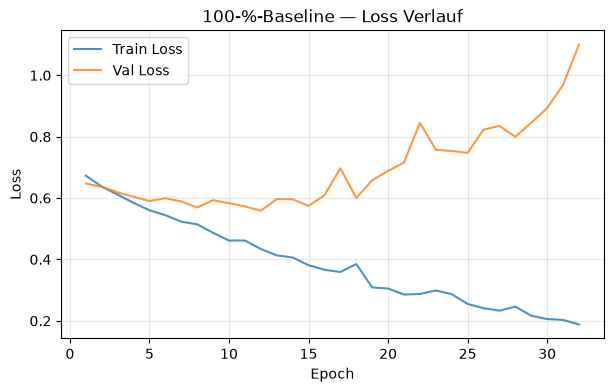

In [25]:
epochs = range(
    1,
    len(train_losses) + 1
)

plt.figure(figsize=(7, 4))

plt.plot(
    epochs,
    train_losses,
    label="Train Loss",
    alpha=0.8
)

plt.plot(
    epochs,
    validation_losses,
    label="Val Loss",
    alpha=0.8
)

plt.title(
    "100-%-Baseline — Loss Verlauf"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(
    True,
    alpha=0.3
)

plt.show()

### Confusion Matrix

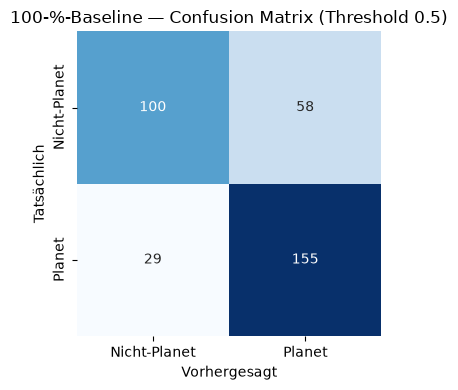

In [26]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    xticklabels=["Nicht-Planet", "Planet"],
    yticklabels=["Nicht-Planet", "Planet"]
)

plt.title(
    f"100-%-Baseline — Confusion Matrix (Threshold {THRESHOLD:.1f})"
)
plt.xlabel("Vorhergesagt")
plt.ylabel("Tatsächlich")
plt.tight_layout()
plt.show()

In [27]:
print("Global View")
print("Minimum:", X_global[train_indices].min())
print("Maximum:", X_global[train_indices].max())
print("Mittelwert:", X_global[train_indices].mean())
print("Standardabweichung:", X_global[train_indices].std())

print()

print("Local View")
print("Minimum:", X_local[train_indices].min())
print("Maximum:", X_local[train_indices].max())
print("Mittelwert:", X_local[train_indices].mean())
print("Standardabweichung:", X_local[train_indices].std())

Global View
Minimum: -20.0
Maximum: 20.0
Mittelwert: -0.1498873
Standardabweichung: 2.6302245

Local View
Minimum: -20.0
Maximum: 20.0
Mittelwert: -0.86361796
Standardabweichung: 4.1384554


#### 50%-Trainingsmenge erzeugen

In [34]:
def create_stratified_subset(
    indices,
    labels,
    fraction,
    seed
):
    rng = np.random.default_rng(seed)

    selected_indices = []

    for label in [0, 1]:
        class_indices = indices[
            labels[indices] == label
        ].copy()

        rng.shuffle(class_indices)

        n_samples = round(
            len(class_indices) * fraction
        )

        selected_indices.extend(
            class_indices[:n_samples]
        )

    return np.array(
        sorted(selected_indices)
    )


train_indices_50 = create_stratified_subset(
    train_indices,
    y,
    fraction=0.5,
    seed=SEED
)

print(
    "100 % Training:",
    len(train_indices)
)

print(
    "50 % Training:",
    len(train_indices_50)
)

print()

print(
    "Klassen 100 %:",
    np.bincount(
        y[train_indices]
    )
)

print(
    "Klassen 50 %:",
    np.bincount(
        y[train_indices_50]
    )
)

100 % Training: 1596
50 % Training: 798

Klassen 100 %: [732 864]
Klassen 50 %: [366 432]


In [35]:
train_dataset_50 = LightCurveDataset(
    X_global,
    X_local,
    y,
    train_indices_50
)

print(
    "50 % Training:",
    len(train_dataset_50)
)

print(
    "Validation:",
    len(validation_dataset)
)

50 % Training: 798
Validation: 342


#### 50%-Baseline über fünf Seeds trainieren

In [39]:
baseline_models_50 = {}
baseline_histories_50 = {}

for experiment_seed in EXPERIMENT_SEEDS:
    set_seed(experiment_seed)

    loader_generator = torch.Generator()
    loader_generator.manual_seed(
        experiment_seed
    )

    seeded_train_loader_50 = DataLoader(
        train_dataset_50,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        generator=loader_generator
    )

    current_model = (
        AstroNetClassifier()
        .to(device)
    )

    current_optimizer = torch.optim.Adam(
        current_model.parameters(),
        lr=LEARNING_RATE
    )

    (
        current_model,
        current_train_losses,
        current_validation_losses
    ) = train_model(
        current_model,
        seeded_train_loader_50,
        validation_loader,
        criterion,
        current_optimizer,
        device,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        verbose=False
    )

    baseline_models_50[
        experiment_seed
    ] = current_model

    baseline_histories_50[
        experiment_seed
    ] = {
        "train_loss":
            current_train_losses,
        "validation_loss":
            current_validation_losses
    }

    print(
        f"Seed {experiment_seed}: "
        f"beste Epoche "
        f"{np.argmin(current_validation_losses) + 1}, "
        f"{len(current_train_losses)} "
        f"Epochen trainiert"
    )


baseline_model_50 = (
    baseline_models_50[SEED]
)

train_losses_50 = (
    baseline_histories_50[SEED][
        "train_loss"
    ]
)

validation_losses_50 = (
    baseline_histories_50[SEED][
        "validation_loss"
    ]
)

Seed 7: beste Epoche 15, 35 Epochen trainiert
Seed 21: beste Epoche 10, 30 Epochen trainiert
Seed 42: beste Epoche 16, 36 Epochen trainiert
Seed 84: beste Epoche 12, 32 Epochen trainiert
Seed 123: beste Epoche 6, 26 Epochen trainiert


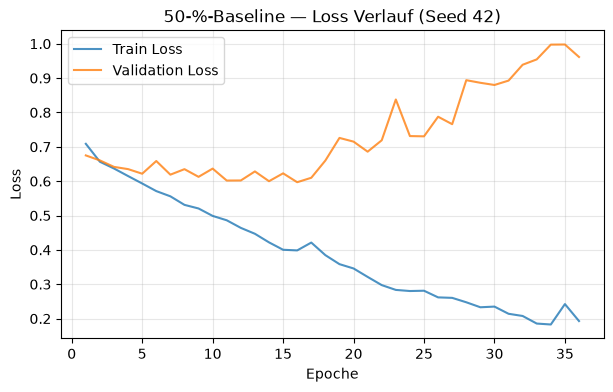

In [41]:
epochs_50 = range(
    1,
    len(train_losses_50) + 1
)

plt.figure(
    figsize=(7, 4)
)

plt.plot(
    epochs_50,
    train_losses_50,
    label="Train Loss",
    alpha=0.8
)

plt.plot(
    epochs_50,
    validation_losses_50,
    label="Validation Loss",
    alpha=0.8
)

plt.title(
    "50-%-Baseline — Loss Verlauf (Seed 42)"
)

plt.xlabel("Epoche")
plt.ylabel("Loss")

plt.legend()
plt.grid(
    True,
    alpha=0.3
)

plt.show()

#### Confusion Matrix

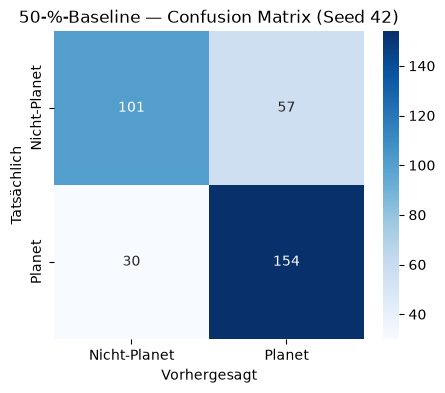

In [46]:
validation_probabilities_50, validation_labels_50 = (
    predict_probabilities(
        baseline_model_50,
        validation_loader,
        device
    )
)

y_true_50 = (
    validation_labels_50
    .numpy()
    .astype(int)
)

y_prob_50 = (
    validation_probabilities_50
    .numpy()
)

y_pred_50 = (
    y_prob_50 >= THRESHOLD
).astype(int)


plt.figure(
    figsize=(5, 4)
)

sns.heatmap(
    cm_50,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Nicht-Planet",
        "Planet"
    ],
    yticklabels=[
        "Nicht-Planet",
        "Planet"
    ]
)

plt.title(
    "50-%-Baseline — Confusion Matrix (Seed 42)"
)

plt.xlabel("Vorhergesagt")
plt.ylabel("Tatsächlich")

plt.show()

#### 50% Baseline auswerten

In [67]:
validation_rows_50 = []

for (
    experiment_seed,
    experiment_model
) in baseline_models_50.items():

    probabilities, labels = (
        predict_probabilities(
            experiment_model,
            validation_loader,
            device
        )
    )

    validation_rows_50.append({
        "seed": experiment_seed,
        **calculate_metrics(
            labels,
            probabilities
        )
    })


validation_results_50 = pd.DataFrame(
    validation_rows_50
)

validation_summary_50 = (
    validation_results_50[
        METRIC_COLUMNS
    ]
    .agg(["mean", "std"])
    .T
)


display(
    validation_results_50
)

display(
    validation_summary_50
    .style
    .format("{:.4f}")
)


primary_validation_50 = (
    validation_summary_50.loc[
        PRIMARY_METRIC
    ]
)

print(
    "50 % Validation ROC-AUC: "
    f"{primary_validation_50['mean']:.4f} "
    "± "
    f"{primary_validation_50['std']:.4f}"
)

,seed,accuracy,precision,recall,f1,roc_auc,average_precision
0,7,0.736842,0.728155,0.815217,0.769231,0.785842,0.777112
1,21,0.725146,0.764706,0.706522,0.734463,0.767302,0.772798
2,42,0.745614,0.729858,0.836957,0.779747,0.807168,0.790436
3,84,0.725146,0.725000,0.788043,0.755208,0.777793,0.768667
4,123,0.675439,0.762590,0.576087,0.656347,0.744324,0.722915


,mean,std
accuracy,0.7216,0.0272
precision,0.7421,0.0198
recall,0.7446,0.1064
f1,0.7390,0.0492
roc_auc,0.7765,0.0232
average_precision,0.7664,0.0256


50 % Validation ROC-AUC: 0.7765 ± 0.0232


#### 25% Baseline

In [47]:
train_indices_25 = create_stratified_subset(
    train_indices,
    y,
    fraction=0.25,
    seed=SEED
)

print(
    "100 % Training:",
    len(train_indices)
)

print(
    "50 % Training:",
    len(train_indices_50)
)

print(
    "25 % Training:",
    len(train_indices_25)
)

print()

print(
    "Klassen 25 %:",
    np.bincount(
        y[train_indices_25]
    )
)

print()

print(
    "25 % ist Teilmenge von 50 %:",
    set(train_indices_25).issubset(
        set(train_indices_50)
    )
)

100 % Training: 1596
50 % Training: 798
25 % Training: 399

Klassen 25 %: [183 216]

25 % ist Teilmenge von 50 %: True


#### Datensatz 25% Baseline

In [48]:
train_dataset_25 = LightCurveDataset(
    X_global,
    X_local,
    y,
    train_indices_25
)

print(
    "25 % Training:",
    len(train_dataset_25)
)

print(
    "Validation:",
    len(validation_dataset)
)

25 % Training: 399
Validation: 342


#### Training 25% Baseline

In [49]:
baseline_models_25 = {}
baseline_histories_25 = {}

for experiment_seed in EXPERIMENT_SEEDS:
    set_seed(experiment_seed)

    loader_generator = torch.Generator()
    loader_generator.manual_seed(
        experiment_seed
    )

    seeded_train_loader_25 = DataLoader(
        train_dataset_25,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        generator=loader_generator
    )

    current_model = (
        AstroNetClassifier()
        .to(device)
    )

    current_optimizer = torch.optim.Adam(
        current_model.parameters(),
        lr=LEARNING_RATE
    )

    (
        current_model,
        current_train_losses,
        current_validation_losses
    ) = train_model(
        current_model,
        seeded_train_loader_25,
        validation_loader,
        criterion,
        current_optimizer,
        device,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        verbose=False
    )

    baseline_models_25[
        experiment_seed
    ] = current_model

    baseline_histories_25[
        experiment_seed
    ] = {
        "train_loss":
            current_train_losses,
        "validation_loss":
            current_validation_losses
    }

    print(
        f"Seed {experiment_seed}: "
        f"beste Epoche "
        f"{np.argmin(current_validation_losses) + 1}, "
        f"{len(current_train_losses)} "
        f"Epochen trainiert"
    )


baseline_model_25 = (
    baseline_models_25[SEED]
)

train_losses_25 = (
    baseline_histories_25[SEED][
        "train_loss"
    ]
)

validation_losses_25 = (
    baseline_histories_25[SEED][
        "validation_loss"
    ]
)

Seed 7: beste Epoche 7, 27 Epochen trainiert
Seed 21: beste Epoche 9, 29 Epochen trainiert
Seed 42: beste Epoche 3, 23 Epochen trainiert
Seed 84: beste Epoche 7, 27 Epochen trainiert
Seed 123: beste Epoche 6, 26 Epochen trainiert


#### Loss-Verlauf visuell

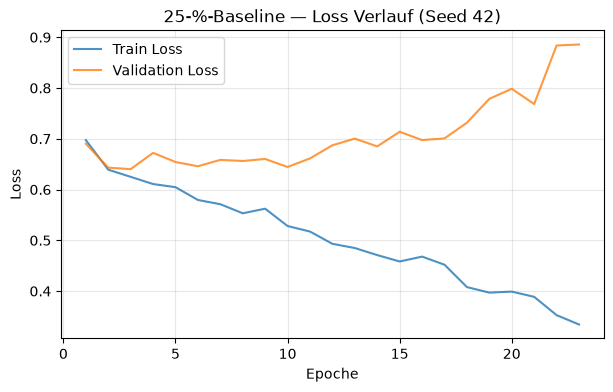

In [51]:
epochs_25 = range(
    1,
    len(train_losses_25) + 1
)

plt.figure(
    figsize=(7, 4)
)

plt.plot(
    epochs_25,
    train_losses_25,
    label="Train Loss",
    alpha=0.8
)

plt.plot(
    epochs_25,
    validation_losses_25,
    label="Validation Loss",
    alpha=0.8
)

plt.title(
    "25-%-Baseline — Loss Verlauf (Seed 42)"
)

plt.xlabel("Epoche")
plt.ylabel("Loss")

plt.legend()
plt.grid(
    True,
    alpha=0.3
)

plt.show()

#### Confusion Matrix 25% Baseline

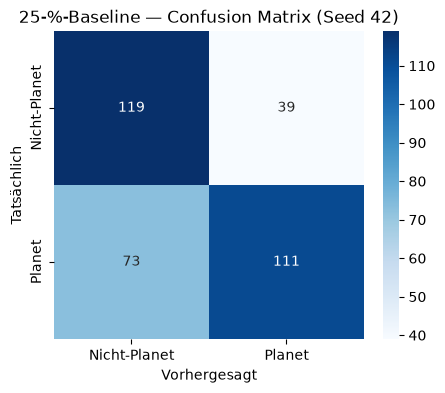

In [54]:
validation_probabilities_25, validation_labels_25 = (
    predict_probabilities(
        baseline_model_25,
        validation_loader,
        device
    )
)

y_true_25 = (
    validation_labels_25
    .numpy()
    .astype(int)
)

y_prob_25 = (
    validation_probabilities_25
    .numpy()
)

y_pred_25 = (
    y_prob_25 >= THRESHOLD
).astype(int)

cm_25 = confusion_matrix(
    y_true_25,
    y_pred_25,
    labels=[0, 1]
)

plt.figure(
    figsize=(5, 4)
)

sns.heatmap(
    cm_25,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Nicht-Planet",
        "Planet"
    ],
    yticklabels=[
        "Nicht-Planet",
        "Planet"
    ]
)

plt.title(
    "25-%-Baseline — Confusion Matrix (Seed 42)"
)

plt.xlabel("Vorhergesagt")
plt.ylabel("Tatsächlich")

plt.show()

#### Auswertung

In [68]:
validation_rows_25 = []

for (
    experiment_seed,
    experiment_model
) in baseline_models_25.items():

    probabilities, labels = (
        predict_probabilities(
            experiment_model,
            validation_loader,
            device
        )
    )

    validation_rows_25.append({
        "seed": experiment_seed,
        **calculate_metrics(
            labels,
            probabilities
        )
    })


validation_results_25 = pd.DataFrame(
    validation_rows_25
)

validation_summary_25 = (
    validation_results_25[
        METRIC_COLUMNS
    ]
    .agg(["mean", "std"])
    .T
)


display(
    validation_results_25
)

display(
    validation_summary_25
    .style
    .format("{:.4f}")
)


primary_validation_25 = (
    validation_summary_25.loc[
        PRIMARY_METRIC
    ]
)

print(
    "25 % Validation ROC-AUC: "
    f"{primary_validation_25['mean']:.4f} "
    "± "
    f"{primary_validation_25['std']:.4f}"
)

,seed,accuracy,precision,recall,f1,roc_auc,average_precision
0,7,0.695906,0.710526,0.733696,0.721925,0.730462,0.716397
1,21,0.695906,0.710526,0.733696,0.721925,0.732354,0.716053
2,42,0.672515,0.740000,0.603261,0.664671,0.720556,0.702985
3,84,0.672515,0.709302,0.663043,0.685393,0.728914,0.716136
4,123,0.681287,0.724551,0.657609,0.689459,0.727504,0.707321


,mean,std
accuracy,0.6836,0.0118
precision,0.7190,0.0133
recall,0.6783,0.0557
f1,0.6967,0.0249
roc_auc,0.7280,0.0045
average_precision,0.7118,0.0062


25 % Validation ROC-AUC: 0.7280 ± 0.0045


#### 10% Baseline Trainingsmenge erzeugen

In [55]:
train_indices_10 = create_stratified_subset(
    train_indices,
    y,
    fraction=0.10,
    seed=SEED
)

print(
    "100 % Training:",
    len(train_indices)
)

print(
    "50 % Training:",
    len(train_indices_50)
)

print(
    "25 % Training:",
    len(train_indices_25)
)

print(
    "10 % Training:",
    len(train_indices_10)
)

print()

print(
    "Klassen 10 %:",
    np.bincount(
        y[train_indices_10]
    )
)

print()

print(
    "10 % ist Teilmenge von 25 %:",
    set(train_indices_10).issubset(
        set(train_indices_25)
    )
)

100 % Training: 1596
50 % Training: 798
25 % Training: 399
10 % Training: 159

Klassen 10 %: [73 86]

10 % ist Teilmenge von 25 %: True


#### 10% Dataset erstellen

In [56]:
train_dataset_10 = LightCurveDataset(
    X_global,
    X_local,
    y,
    train_indices_10
)

print(
    "10 % Training:",
    len(train_dataset_10)
)

print(
    "Validation:",
    len(validation_dataset)
)

10 % Training: 159
Validation: 342


#### 10% Baseline trainieren

In [57]:
baseline_models_10 = {}
baseline_histories_10 = {}

for experiment_seed in EXPERIMENT_SEEDS:
    set_seed(experiment_seed)

    loader_generator = torch.Generator()
    loader_generator.manual_seed(
        experiment_seed
    )

    seeded_train_loader_10 = DataLoader(
        train_dataset_10,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        generator=loader_generator
    )

    current_model = (
        AstroNetClassifier()
        .to(device)
    )

    current_optimizer = torch.optim.Adam(
        current_model.parameters(),
        lr=LEARNING_RATE
    )

    (
        current_model,
        current_train_losses,
        current_validation_losses
    ) = train_model(
        current_model,
        seeded_train_loader_10,
        validation_loader,
        criterion,
        current_optimizer,
        device,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        verbose=False
    )

    baseline_models_10[
        experiment_seed
    ] = current_model

    baseline_histories_10[
        experiment_seed
    ] = {
        "train_loss":
            current_train_losses,
        "validation_loss":
            current_validation_losses
    }

    print(
        f"Seed {experiment_seed}: "
        f"beste Epoche "
        f"{np.argmin(current_validation_losses) + 1}, "
        f"{len(current_train_losses)} "
        f"Epochen trainiert"
    )


baseline_model_10 = (
    baseline_models_10[SEED]
)

train_losses_10 = (
    baseline_histories_10[SEED][
        "train_loss"
    ]
)

validation_losses_10 = (
    baseline_histories_10[SEED][
        "validation_loss"
    ]
)

Seed 7: beste Epoche 6, 26 Epochen trainiert
Seed 21: beste Epoche 10, 30 Epochen trainiert
Seed 42: beste Epoche 7, 27 Epochen trainiert
Seed 84: beste Epoche 9, 29 Epochen trainiert
Seed 123: beste Epoche 6, 26 Epochen trainiert


#### Loss visuell

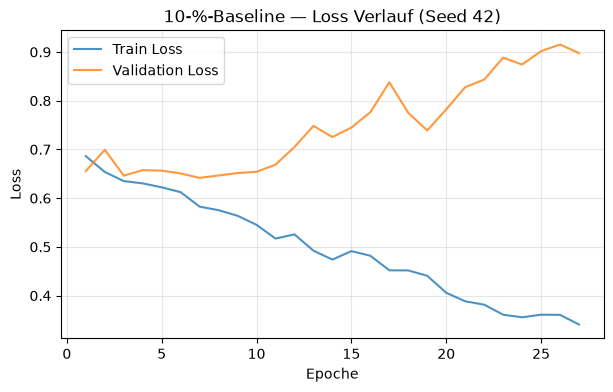

In [59]:
epochs_10 = range(
    1,
    len(train_losses_10) + 1
)

plt.figure(
    figsize=(7, 4)
)

plt.plot(
    epochs_10,
    train_losses_10,
    label="Train Loss",
    alpha=0.8
)

plt.plot(
    epochs_10,
    validation_losses_10,
    label="Validation Loss",
    alpha=0.8
)

plt.title(
    "10-%-Baseline — Loss Verlauf (Seed 42)"
)

plt.xlabel("Epoche")
plt.ylabel("Loss")

plt.legend()
plt.grid(
    True,
    alpha=0.3
)

plt.show()

#### Confusion Matrix 10 % Baseline

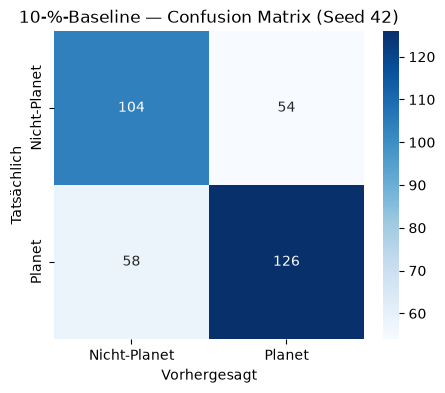

In [61]:
validation_probabilities_10, validation_labels_10 = (
    predict_probabilities(
        baseline_model_10,
        validation_loader,
        device
    )
)

y_true_10 = (
    validation_labels_10
    .numpy()
    .astype(int)
)

y_prob_10 = (
    validation_probabilities_10
    .numpy()
)

y_pred_10 = (
    y_prob_10 >= THRESHOLD
).astype(int)

cm_10 = confusion_matrix(
    y_true_10,
    y_pred_10,
    labels=[0, 1]
)

plt.figure(
    figsize=(5, 4)
)

sns.heatmap(
    cm_10,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Nicht-Planet",
        "Planet"
    ],
    yticklabels=[
        "Nicht-Planet",
        "Planet"
    ]
)

plt.title(
    "10-%-Baseline — Confusion Matrix (Seed 42)"
)

plt.xlabel("Vorhergesagt")
plt.ylabel("Tatsächlich")

plt.show()

#### 10% Baseline Auswertung

In [69]:
validation_rows_10 = []

for (
    experiment_seed,
    experiment_model
) in baseline_models_10.items():

    probabilities, labels = (
        predict_probabilities(
            experiment_model,
            validation_loader,
            device
        )
    )

    validation_rows_10.append({
        "seed": experiment_seed,
        **calculate_metrics(
            labels,
            probabilities
        )
    })


validation_results_10 = pd.DataFrame(
    validation_rows_10
)

validation_summary_10 = (
    validation_results_10[
        METRIC_COLUMNS
    ]
    .agg(["mean", "std"])
    .T
)


display(
    validation_results_10
)

display(
    validation_summary_10
    .style
    .format("{:.4f}")
)


primary_validation_10 = (
    validation_summary_10.loc[
        PRIMARY_METRIC
    ]
)

print(
    "10 % Validation ROC-AUC: "
    f"{primary_validation_10['mean']:.4f} "
    "± "
    f"{primary_validation_10['std']:.4f}"
)

,seed,accuracy,precision,recall,f1,roc_auc,average_precision
0,7,0.646199,0.693252,0.614130,0.651297,0.693313,0.676092
1,21,0.663743,0.711656,0.630435,0.668588,0.711303,0.697853
2,42,0.672515,0.700000,0.684783,0.692308,0.719902,0.699857
3,84,0.660819,0.693182,0.663043,0.677778,0.707554,0.700749
4,123,0.649123,0.710526,0.586957,0.642857,0.713573,0.691774


,mean,std
accuracy,0.6585,0.0108
precision,0.7017,0.0090
recall,0.6359,0.0388
f1,0.6666,0.0199
roc_auc,0.7091,0.0099
average_precision,0.6933,0.0102


10 % Validation ROC-AUC: 0.7091 ± 0.0099


#### Vergleich aller Baselines für supervised training

In [70]:
supervised_summaries = {
    100: (
        len(train_indices),
        validation_summary
    ),
    50: (
        len(train_indices_50),
        validation_summary_50
    ),
    25: (
        len(train_indices_25),
        validation_summary_25
    ),
    10: (
        len(train_indices_10),
        validation_summary_10
    )
}


comparison_rows = []

for (
    label_fraction,
    (
        n_train,
        summary
    )
) in supervised_summaries.items():

    row = {
        "labels_percent": label_fraction,
        "train_samples": n_train
    }

    for metric in METRIC_COLUMNS:
        row[
            f"{metric}_mean"
        ] = summary.loc[
            metric,
            "mean"
        ]

        row[
            f"{metric}_std"
        ] = summary.loc[
            metric,
            "std"
        ]

    comparison_rows.append(row)


supervised_results_summary = (
    pd.DataFrame(
        comparison_rows
    )
    .sort_values(
        "labels_percent",
        ascending=False
    )
    .reset_index(drop=True)
)


supervised_comparison = pd.DataFrame({
    "Labels": (
        supervised_results_summary[
            "labels_percent"
        ]
        .astype(str)
        + " %"
    ),

    "Trainingssamples":
        supervised_results_summary[
            "train_samples"
        ],

    "Accuracy":
        supervised_results_summary.apply(
            lambda row:
            f"{row['accuracy_mean']:.4f} "
            f"± {row['accuracy_std']:.4f}",
            axis=1
        ),

    "Precision":
        supervised_results_summary.apply(
            lambda row:
            f"{row['precision_mean']:.4f} "
            f"± {row['precision_std']:.4f}",
            axis=1
        ),

    "Recall":
        supervised_results_summary.apply(
            lambda row:
            f"{row['recall_mean']:.4f} "
            f"± {row['recall_std']:.4f}",
            axis=1
        ),

    "F1":
        supervised_results_summary.apply(
            lambda row:
            f"{row['f1_mean']:.4f} "
            f"± {row['f1_std']:.4f}",
            axis=1
        ),

    "ROC-AUC":
        supervised_results_summary.apply(
            lambda row:
            f"{row['roc_auc_mean']:.4f} "
            f"± {row['roc_auc_std']:.4f}",
            axis=1
        ),

    "Average Precision":
        supervised_results_summary.apply(
            lambda row:
            f"{row['average_precision_mean']:.4f} "
            f"± {row['average_precision_std']:.4f}",
            axis=1
        )
})


display(
    supervised_comparison
)

,Labels,Trainingssamples,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,100 %,1596,0.7427 ± 0.0140,0.7747 ± 0.0335,0.7424 ± 0.0807,0.7549 ± 0.0282,0.8134 ± 0.0127,0.8063 ± 0.0140
1,50 %,798,0.7216 ± 0.0272,0.7421 ± 0.0198,0.7446 ± 0.1064,0.7390 ± 0.0492,0.7765 ± 0.0232,0.7664 ± 0.0256
2,25 %,399,0.6836 ± 0.0118,0.7190 ± 0.0133,0.6783 ± 0.0557,0.6967 ± 0.0249,0.7280 ± 0.0045,0.7118 ± 0.0062
3,10 %,159,0.6585 ± 0.0108,0.7017 ± 0.0090,0.6359 ± 0.0388,0.6666 ± 0.0199,0.7091 ± 0.0099,0.6933 ± 0.0102


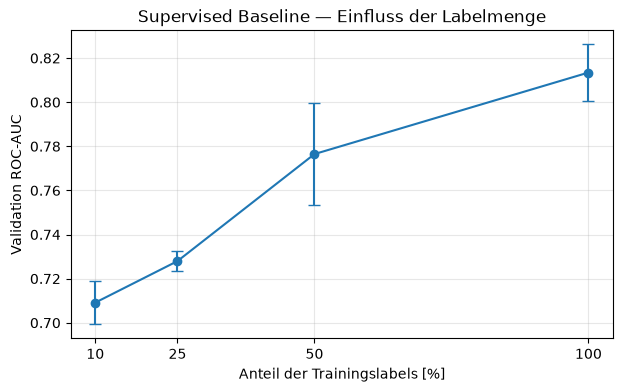

In [63]:
plot_data = (
    supervised_results_summary
    .sort_values(
        "labels_percent"
    )
)

plt.figure(
    figsize=(7, 4)
)

plt.errorbar(
    plot_data["labels_percent"],
    plot_data["roc_auc_mean"],
    yerr=plot_data["roc_auc_std"],
    marker="o",
    capsize=4
)

plt.xlabel(
    "Anteil der Trainingslabels [%]"
)

plt.ylabel(
    "Validation ROC-AUC"
)

plt.title(
    "Supervised Baseline — Einfluss der Labelmenge"
)

plt.xticks(
    [10, 25, 50, 100]
)

plt.grid(
    True,
    alpha=0.3
)

plt.show()

#### Speichere Label Teilmengen

In [71]:
SUBSET_FILE = (
    DATA_DIR
    / "supervised_label_subsets.npz"
)

np.savez_compressed(
    SUBSET_FILE,
    train_indices_100=train_indices,
    train_indices_50=train_indices_50,
    train_indices_25=train_indices_25,
    train_indices_10=train_indices_10
)

print(
    "Gespeichert:",
    SUBSET_FILE
)

print()
print("100 %:", len(train_indices))
print("50 %:", len(train_indices_50))
print("25 %:", len(train_indices_25))
print("10 %:", len(train_indices_10))

Gespeichert: c:\Users\User\Documents\VanessaExoplanets\Exoplanets\data\processed\spoc120_dataset\supervised_label_subsets.npz

100 %: 1596
50 %: 798
25 %: 399
10 %: 159


#### Ergebnisse und Modelle speichern

In [72]:
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "supervised"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SUMMARY_FILE = (
    RESULTS_DIR
    / "supervised_validation_summary.csv"
)

supervised_results_summary.to_csv(
    SUMMARY_FILE,
    index=False
)

model_groups = {
    100: baseline_models,
    50: baseline_models_50,
    25: baseline_models_25,
    10: baseline_models_10
}

for label_fraction, models in model_groups.items():
    for experiment_seed, trained_model in models.items():

        model_file = (
            RESULTS_DIR
            / (
                f"baseline_{label_fraction}pct_"
                f"seed_{experiment_seed}.pt"
            )
        )

        torch.save(
            trained_model.state_dict(),
            model_file
        )


print(
    "Ergebnisse gespeichert:",
    SUMMARY_FILE
)

print(
    "Gespeicherte Modelle:",
    sum(
        len(models)
        for models in model_groups.values()
    )
)

Ergebnisse gespeichert: c:\Users\User\Documents\VanessaExoplanets\Exoplanets\results\supervised\supervised_validation_summary.csv
Gespeicherte Modelle: 20


## Ergebnis

In diesem Notebook wurde ein AstroNet-artiges 1D-CNN als vollständig
supervised Baseline für die binäre Klassifikation von TESS-Lichtkurven
trainiert.

Das Modell wurde dabei mit vier Anteilen der verfügbaren Trainingslabels trainiert:

- 100 %: 1596 Samples
- 50 %: 798 Samples
- 25 %: 399 Samples
- 10 %: 159 Samples


Validation und Test wurden dabei nicht verändert.

Für jeden Label-Anteil wurden fünf Trainingsläufe mit den festen Seeds
7, 21, 42, 84 und 123 durchgeführt. Early Stopping basierte auf dem
Validation Loss.

Die mittlere ROC-AUC über die fünf Seeds beträgt:

- 100 % Labels: 0.8134 ± 0.0127
- 50 % Labels: 0.7765 ± 0.0232
- 25 % Labels: 0.7280 ± 0.0045
- 10 % Labels: 0.7091 ± 0.0099

Mit abnehmender Anzahl verfügbarer Trainingslabels sinkt damit die
Klassifikationsleistung der vollständig supervised trainierten Modelle.

Neben ROC-AUC wurden Accuracy, Precision, Recall, F1 und
Average Precision (AP) ausgewertet.

### Gespeicherte Ergebnisse

Die exakten Label-Teilmengen wurden unter `data/processed/spoc120_dataset/supervised_label_subsets.npz` gespeichert.

Die Validation-Ergebnisse sowie die Modellgewichte aller
20 Trainingsläufe wurden unter `results/supervised/` gespeichert.

Diese Ergebnisse bilden die Referenz für den anschließenden Vergleich
mit Self-Supervised Pretraining.